In [1]:
# Load packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmaps
from matplotlib.colors import LinearSegmentedColormap
import time
import sys
import gc  # 垃圾回收
import pickle  # 用于保存检查点
from datetime import datetime

from scipy import signal
import dask.array as da

print("="*70)
print("✅ Packages loaded successfully")
print("="*70)

# Set up directories
DATA_DIR = "./processed_data"
fig_save_dir = "./figures/Cal_cckws_std_distribution/"
CACHE_DIR = "./cache/kelvin_wave/"  # 新增：缓存目录
CHECKPOINT_DIR = "./checkpoints/"   # 新增：检查点目录

for d in [fig_save_dir, CACHE_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Figure save directory: {fig_save_dir}")
print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📁 Checkpoint directory: {CHECKPOINT_DIR}")
print("="*70)

✅ Packages loaded successfully
📁 Data directory: ./processed_data
📁 Figure save directory: ./figures/Cal_cckws_std_distribution/
📁 Cache directory: ./cache/kelvin_wave/
📁 Checkpoint directory: ./checkpoints/


In [2]:
# 新增：辅助函数

def save_checkpoint(data, step_name, exp_name):
    """保存检查点"""
    checkpoint_file = os.path.join(CHECKPOINT_DIR, f"{step_name}_{exp_name}.pkl")
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(data, f)
    print(f"  💾 Checkpoint saved: {checkpoint_file}")

def load_checkpoint(step_name, exp_name):
    """加载检查点"""
    checkpoint_file = os.path.join(CHECKPOINT_DIR, f"{step_name}_{exp_name}.pkl")
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, 'rb') as f:
            data = pickle.load(f)
        print(f"  ♻️ Checkpoint loaded: {checkpoint_file}")
        return data
    return None

def format_time(seconds):
    """格式化时间显示"""
    if seconds < 60:
        return f"{seconds:.1f}秒"
    elif seconds < 3600:
        return f"{seconds/60:.1f}分钟"
    else:
        return f"{seconds/3600:.1f}小时"

print("✅ 辅助函数定义完成")

✅ 辅助函数定义完成


In [3]:
# 创建colormap
def create_improved_colormap():
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

In [4]:





import numpy as np
from scipy import signal
import xarray as xr
import matplotlib.pyplot as plt
import dask.array as da

# 切换到脚本所在的目录

"""
Created on Mon Mar  3 15:25:08 2025

@author: xpji

connect me : xianpuji@hhu.edu.cn

This script is used to filter waves in the OLR data using dask for parallel processing. Only support Kelvin and ER waves.

The script is based on the NCL example: 
- https://www.ncl.ucar.edu/Document/Functions/User_contributed/kf_filter.shtml
and
- https://github.com/Blissful-Jasper/mcclimate/blob/master/kf_filter.py

The script is tested on the OLR data from the NCL example and the results are validated against the NCL output.

"""



class WaveFilter:
    def __init__(self, ds=None, var=None, sel_dict=None, wave_name=None, units=None, spd=1,  n_workers=4):
        
        self.sel_dict = sel_dict
        self.wave_name = wave_name
        self.n_workers = n_workers
        self.spd       = spd  # obs_per_day, if one day have four times sample ,then spd=4
        self.data = None
        self.units = units
        self.filtered_data = None
        self.fftdata = None
        self.var =var
        if isinstance(ds, str):  # 如果是文件路径，读取 NetCDF 文件
            self.ds = xr.open_dataset(ds, chunks={'time': 'auto'})
        elif isinstance(ds, (xr.Dataset, xr.DataArray)):  # 直接传入 xarray 数据
            self.ds = ds
        else:
            raise ValueError("`data` 必须是文件路径 (str) 或 `xarray.Dataset` / `xarray.DataArray`")
            
    def __repr__(self):
        # 优先从 sel_dict 中提取 lat/time（更统一）
        lat_sel = self.sel_dict.get('lat') if self.sel_dict and 'lat' in self.sel_dict else self.lat_range
        time_sel = self.sel_dict.get('time') if self.sel_dict and 'time' in self.sel_dict else self.time_range
    
        lines = [
            "📡 WaveFilter Summary:",
            f"  • Wave Type     : {self.wave_name or 'N/A'}",
            f"  • Variable      : {self.var or 'N/A'}",
            f"  • Time Range    : {time_sel or 'N/A'}",
            f"  • Latitude Range: {lat_sel or 'N/A'}",
            f"  • Units         : {self.units or 'N/A'}",
            f"  • Workers       : {self.n_workers}",
            f"  • Sampling/day  : {self.spd}",
        ]
        if self.data is not None:
            lines.append(f"  • Data Shape    : {self.data.shape}")
            lines.append(f"  • Data Dims     : {tuple(self.data.dims)}")
        else:
            lines.append("  • Data          : Not loaded")
        return "\n".join(lines)

    
       
    def print_diagnostic_info(self, variable, name):
        """打印变量的诊断信息"""
        try:
            print(f"\n=================={name} Information ====================")
            print(f"Type: {type(variable)}")
            print(f"Shape: {variable.shape}")
            if isinstance(variable, (da.Array, np.ndarray, xr.DataArray)):
                print(f"Data type: {variable.dtype}")
            if isinstance(variable, da.Array):
                print(f"Chunks: {variable.chunks}")
            print(f"First few values: {variable[:5]}")  # 只打印前5个值
            print("=============================================================")
        except Exception as e:
            print(f"Error printing info for {name}: {e}")
            
    def load_data(self):
        """Load and preprocess data."""
    
        if isinstance(self.ds, xr.Dataset):
            self.data = self.ds[self.var].sortby('lat')
        elif isinstance(self.ds, xr.DataArray):
            self.data = self.ds.sortby('lat')
    
        # === 构建 sel_dict ===
        sel_kwargs = {}
    
        if self.sel_dict:
            sel_kwargs.update(self.sel_dict)  # ✅ 直接使用传入的 sel 字典
    
        # 如果用户没有用 sel_dict，而是用了旧的 time_range / lat_range，也兼容
        else:
            if self.time_range:
                t1, t2 = self.time_range
                sel_kwargs['time'] = slice(t1, t2)
            if self.lat_range:
                lat1, lat2 = sorted(self.lat_range)
                sel_kwargs['lat'] = slice(lat1, lat2)
    
        # 应用筛选
        if sel_kwargs:
            self.data = self.data.sel(**sel_kwargs)
    
        self.data = self.data.sortby('lat').transpose('time', 'lat', 'lon')
        self.data = self.data.chunk({'time': -1})
    
        self.print_diagnostic_info(self.data, 'Loaded Data')
        
        
    
        
    def detrend_data(self):
        """Detrend the data using dask for parallel processing."""
        ntim, nlat, nlon = self.data.shape
        spd = self.spd # obs_per_day, if one day have four times sample ,then spd=4
       
        data_rechunked = self.data.data.rechunk({0: -1})
        if ntim >  365*spd/3:
            # 进行并行 FFT
            rf = da.fft.rfft(data_rechunked, axis=0)
            freq = da.fft.rfftfreq(ntim * spd, d=1. / float(spd))
            rf[(freq <= 3. / 365) & (freq >= 1. / 365), :, :] = 0.0
            datain = da.fft.irfft(rf, axis=0, n=ntim)
 
        # 使用 dask 并行去趋势
        self.detrend = da.apply_along_axis(signal.detrend, 0, datain)
    
        window = signal.windows.tukey(self.data.shape[0],0.05,True)
        
        self.detrend = self.detrend * window[:, np.newaxis, np.newaxis]   
        
    def fft_transform(self):
        """Perform 2D FFT on the detrended data using dask."""
        
        # data.shape[2] is the length of lon
        self.wavenumber = -da.fft.fftfreq(self.data.shape[2]) * self.data.shape[2]   # shape: (lon,)
        self.frequency = da.fft.fftfreq(self.data.shape[0], d=1. / float(1))    # shape: (time,)
        # print("\nFrequency values:")
        # print(self.frequency.compute())
        # print("\nFirst 10 frequency values:")
        # print(self.frequency[:10].compute())
        # print("\nWavenumber values:")
        # print(self.wavenumber.compute())
        self.knum_ori, self.freq_ori = da.meshgrid(self.wavenumber, self.frequency)   # shape: (time, lon)
        self.knum = self.knum_ori.copy()
        # print(self.knum_ori.compute().shape)
        self.knum = da.where(self.freq_ori < 0, -self.knum_ori, self.knum_ori)   # shape: (time, lon)
        
        
        
        self.freq = da.abs(self.freq_ori)    # shape: (time, lon)
    
    def apply_filter(self):
        """Apply filter based on wave type."""
        if self.wave_name.lower() == "kelvin":
            self.tMin, self.tMax = 3, 20
            self.kmin, self.kmax = 2, 14
            self.hmin, self.hmax = 8, 90
        elif self.wave_name.lower() == "er":
            self.tMin, self.tMax = 9, 72
            self.kmin, self.kmax = -10, -1
            self.hmin, self.hmax = 8, 90
        self.fmin, self.fmax = 1 / self.tMax, 1 / self.tMin
        self.mask =  da.zeros((self.data.shape[0], self.data.shape[2]), dtype=bool)

     
        
        if self.kmin is not None:
            self.mask = self.mask | (self.knum < self.kmin)
        if self.kmax is not None:
            self.mask = self.mask | (self.kmax < self.knum)

        if self.fmin is not None:
            self.mask = self.mask | (self.freq < self.fmin)
        if self.fmax is not None:
            self.mask = self.mask | (self.fmax < self.freq)

        if self.wave_name.lower() == 'kelvin':
            self.apply_wave_filter(self.wave_name)
        elif self.wave_name.lower() == 'er':
            self.apply_wave_filter(self.wave_name)
            
        # plt.contourf(self.mask[:,:].compute())
        self.fftdata = da.fft.fft2(self.detrend, axes=(0, 2)) # shape: (time, lat, lon)
        self.mask = da.repeat(self.mask[:, np.newaxis, :], self.data.shape[1], axis=1)
     
        # self.fftdata[self.mask] = 0.0
        self.fftdata = da.where(self.mask, 0.0, self.fftdata)
        
    def apply_wave_filter(self,wave_name):
        """Apply Kelvin wave filter."""
        g = 9.8
        beta = 2.28e-11
        a = 6.37e6
        n = 1 
        if self.wave_name.lower() == "kelvin":
            
            if self.hmin is not None:
                c = da.sqrt(g * self.hmin)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega - k < 0)
            if self.hmax is not None:
                c = da.sqrt(g * self.hmax)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega - k > 0)
    
        if self.wave_name.lower() == "er":
    
            if self.hmin is not None:
                c = da.sqrt(g * self.hmin)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega * (k ** 2 + (2 * n + 1)) + k < 0)
            if self.hmax is not None:
                c = da.sqrt(g * self.hmax)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega * (k ** 2 + (2 * n + 1)) + k > 0)
         # if wavename.lower() == "er":
         
         
         
         
    def inverse_fft(self):
        """Perform inverse FFT to get filtered data."""
        self.filtered_data = da.fft.ifft2(self.fftdata, axes=(0, 2)).real

    def create_output(self):
        """Create xarray DataArray for filtered data."""
        self.wave_data = xr.DataArray(self.filtered_data.compute(),  # 将 dask 数组转换为 numpy 数组
                                      coords = {'time': self.data.time,
                                                'lat': self.data.lat,
                                                'lon': self.data.lon},
                                          
                                      dims=['time', 'lat', 'lon'])
        self.wave_data.attrs.update({
            'long_name': self.wave_name,
            'min_equiv_depth': self.hmin,
            'max_equiv_depth': self.hmax,
            'min_wavenumber': self.kmin,
            'max_wavenumber': self.kmax,
            'min_period': self.tMin,
            'max_period': self.tMax,
            'min_frequency': self.fmin,
            'max_frequency': self.fmax,
            
            'units': self.units,

        })
        
        
        return self.wave_data.compute()





In [5]:
# Step 1: Load precipitation data
print("="*70)
print("📊 Loading precipitation data")
print("="*70)

pr_files = {
    'CNTL': os.path.join(DATA_DIR, 'pr_cntl_2deg_interp.nc'),
    'P4K': os.path.join(DATA_DIR, 'pr_4k_2deg_interp.nc'),
    '4CO2': os.path.join(DATA_DIR, 'pr_4co2_2deg_interp.nc')
}

pr_data = {}
for exp, file_path in pr_files.items():
    try:
        data = xr.open_dataarray(file_path)
        pr_data[exp] = data * 86400
        print(f"✅ {exp}: {pr_data[exp].shape} - Converted to mm/day")
    except Exception as e:
        print(f"❌ {exp}: Failed to load - {str(e)}")

print("\n" + "="*70)
print("✅ Precipitation data loaded successfully")
print("="*70)

📊 Loading precipitation data
✅ CNTL: (5114, 15, 180) - Converted to mm/day
✅ P4K: (5114, 15, 180) - Converted to mm/day
✅ 4CO2: (5114, 15, 180) - Converted to mm/day

✅ Precipitation data loaded successfully


In [6]:
# Step 2: Apply Kelvin wave filter - 优化版本
print("="*70)
print("🌊 Applying Kelvin wave filter (with caching)")
print("="*70)

sel_dict = {
    'time': slice('1980-01-01', '1993-12-31'),
    'lat': slice(-15, 15)
}
wave_name = 'kelvin'

kelvin_wave_data = {}
total_start_time = time.time()

for i, exp in enumerate(['CNTL', 'P4K', '4CO2'], 1):
    print(f"\n{'='*60}")
    print(f"📍 Processing {exp} ({i}/3)")
    print(f"{'='*60}")
    
    # 检查缓存
    cache_file = os.path.join(CACHE_DIR, f'kelvin_wave_{exp.lower()}_cached.nc')
    
    if os.path.exists(cache_file):
        print(f"  ♻️ Loading from cache...")
        kelvin_wave_data[exp] = xr.open_dataarray(cache_file)
        print(f"  ✅ {exp} loaded from cache! Shape: {kelvin_wave_data[exp].shape}")
        continue
    
    # 如果没有缓存，进行计算
    exp_start_time = time.time()
    
    wave_filter = WaveFilter(
        ds=pr_data[exp], 
        sel_dict=sel_dict, 
        wave_name=wave_name, 
        units='mm/day', 
        spd=1,
        n_workers=4
    )
    
    print(f"  ⏳ Step 1/5: Loading data...")
    wave_filter.load_data()
    
    print(f"  ⏳ Step 2/5: Detrending data...")
    wave_filter.detrend_data()
    
    print(f"  ⏳ Step 3/5: FFT transform...")
    wave_filter.fft_transform()
    
    print(f"  ⏳ Step 4/5: Applying filter...")
    wave_filter.apply_filter()
    
    print(f"  ⏳ Step 5/5: Inverse FFT...")
    wave_filter.inverse_fft()
    filtered_data = wave_filter.create_output()
    
    # 保存到缓存
    print(f"  💾 Saving to cache...")
    filtered_data.to_netcdf(cache_file)
    
    kelvin_wave_data[exp] = filtered_data
    
    exp_elapsed = time.time() - exp_start_time
    print(f"  ✅ {exp} completed in {format_time(exp_elapsed)}")
    print(f"     Shape: {filtered_data.shape}")
    
    # 清理内存
    del wave_filter, filtered_data
    gc.collect()
    
    # 估算剩余时间
    if i < 3:
        avg_time_per_exp = (time.time() - total_start_time) / i
        remaining_exps = 3 - i
        estimated_remaining = avg_time_per_exp * remaining_exps
        print(f"  📊 预计剩余时间: {format_time(estimated_remaining)}")

total_elapsed = time.time() - total_start_time
print("\n" + "="*70)
print(f"✅ All experiments filtered successfully in {format_time(total_elapsed)}")
print("="*70)

🌊 Applying Kelvin wave filter (with caching)

📍 Processing CNTL (1/3)
  ♻️ Loading from cache...
  ✅ CNTL loaded from cache! Shape: (5114, 15, 180)

📍 Processing P4K (2/3)
  ♻️ Loading from cache...
  ✅ P4K loaded from cache! Shape: (5114, 15, 180)

📍 Processing 4CO2 (3/3)
  ♻️ Loading from cache...
  ✅ 4CO2 loaded from cache! Shape: (5114, 15, 180)

✅ All experiments filtered successfully in 0.2秒


In [7]:
# Step 3: Calculate standard deviation for each experiment
print("="*70)
print("📈 Calculating standard deviation along time dimension")
print("="*70)

kelvin_std = {}

for exp in ['CNTL', 'P4K', '4CO2']:
    # Calculate std along time dimension
    std_data = kelvin_wave_data[exp].std(dim='time')
    kelvin_std[exp] = std_data
    
    print(f"✅ {exp} STD: shape={std_data.shape}, "
          f"min={std_data.min().values:.3f}, "
          f"max={std_data.max().values:.3f}, "
          f"mean={std_data.mean().values:.3f} mm/day")

print("\n" + "="*70)
print("✅ Standard deviation calculated for all experiments")
print("="*70)

📈 Calculating standard deviation along time dimension
✅ CNTL STD: shape=(15, 180), min=0.869, max=3.688, mean=1.899 mm/day
✅ P4K STD: shape=(15, 180), min=1.057, max=4.512, mean=2.250 mm/day
✅ 4CO2 STD: shape=(15, 180), min=0.829, max=3.617, mean=1.859 mm/day

✅ Standard deviation calculated for all experiments


🎨 Plotting spatial distribution of Kelvin wave STD

✅ Figure saved to: ./figures/Cal_cckws_std_distribution/kelvin_wave_std_all_experiments.png


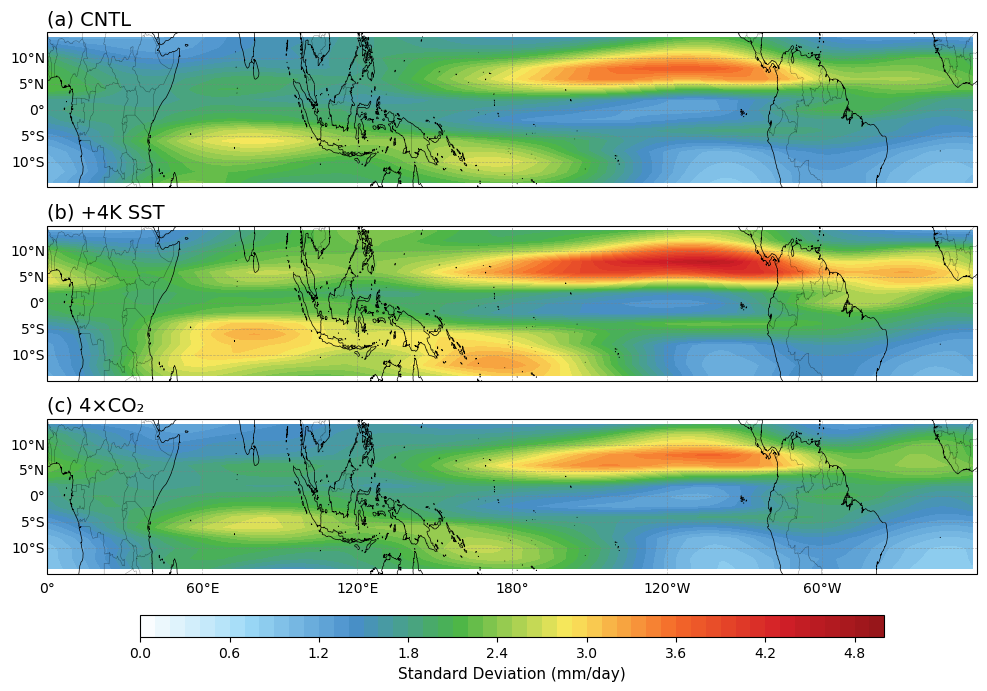

✅ Plotting completed successfully


In [8]:
# Step 4: Plot spatial distribution of STD for all three experiments
print("="*70)
print("🎨 Plotting spatial distribution of Kelvin wave STD")
print("="*70)

fig = plt.figure(figsize=(12, 9))

experiments = ['CNTL', 'P4K', '4CO2']
titles = ['(a) CNTL', '(b) +4K SST', '(c) 4×CO₂']

# Determine common colorbar range
vmin = min([kelvin_std[exp].min().values for exp in experiments])
vmax = max([kelvin_std[exp].max().values for exp in experiments])
ax_list= []
for i, (exp, title) in enumerate(zip(experiments, titles), 1):
    ax = plt.subplot(3, 1, i, projection=ccrs.PlateCarree(central_longitude=180))
    ax_list.append(ax)
    # Plot data
    data = kelvin_std[exp]
    im = ax.contourf(
        data.lon, 
        data.lat, 
        data,
        levels=np.linspace(0, 5, 51),
        cmap=cmaps.WhiteBlueGreenYellowRed,
        transform=ccrs.PlateCarree(),
        extend='neither'
    )
    
    # Add coastlines and features
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    
    # Set extent and gridlines
    ax.set_extent([0, 360, -15, 15], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if i < 3:
        gl.bottom_labels = False
    
    # Title
    ax.set_title(f'{title}', fontsize=14, loc='left')
    ax.set_aspect(2)
    # Colorbar for each subplot
cbar = plt.colorbar(im, ax=ax_list, orientation='horizontal', pad=0.06, shrink=0.8,aspect=35)
cbar.set_label('Standard Deviation (mm/day)', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# plt.tight_layout()

# Save figure
save_path = os.path.join(fig_save_dir, 'kelvin_wave_std_all_experiments.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Figure saved to: {save_path}")

plt.show()

print("="*70)
print("✅ Plotting completed successfully")
print("="*70)

📊 Calculating differences between experiments
P4K - CNTL: min=-0.066, max=0.852, mean=0.351 mm/day
4CO2 - CNTL: min=-0.391, max=0.411, mean=-0.040 mm/day



✅ Figure saved to: ./figures/Cal_cckws_std_distribution/kelvin_wave_std_differences.png


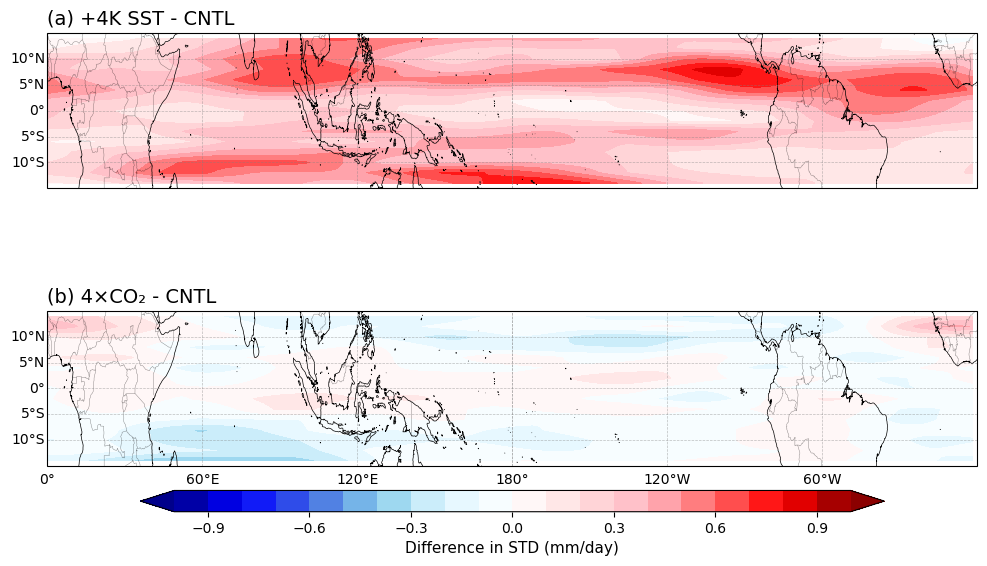

✅ Difference plotting completed


In [9]:
# Step 5 (Optional): Calculate and plot differences between experiments
print("="*70)
print("📊 Calculating differences between experiments")
print("="*70)

# Calculate differences
diff_p4k_cntl = kelvin_std['P4K'] - kelvin_std['CNTL']
diff_4co2_cntl = kelvin_std['4CO2'] - kelvin_std['CNTL']

print(f"P4K - CNTL: min={diff_p4k_cntl.min().values:.3f}, "
      f"max={diff_p4k_cntl.max().values:.3f}, "
      f"mean={diff_p4k_cntl.mean().values:.3f} mm/day")

print(f"4CO2 - CNTL: min={diff_4co2_cntl.min().values:.3f}, "
      f"max={diff_4co2_cntl.max().values:.3f}, "
      f"mean={diff_4co2_cntl.mean().values:.3f} mm/day")

# Plot differences
fig = plt.figure(figsize=(12, 7))

diffs = [diff_p4k_cntl, diff_4co2_cntl]
diff_titles = ['(a) +4K SST - CNTL', '(b) 4×CO₂ - CNTL']

# Determine symmetric colorbar range
abs_max = max([abs(diff.min().values) for diff in diffs] + 
              [abs(diff.max().values) for diff in diffs])
vlim = abs_max
ax_list = []
for i, (diff, title) in enumerate(zip(diffs, diff_titles), 1):
    ax = plt.subplot(2, 1, i, projection=ccrs.PlateCarree(central_longitude=180))
    ax_list.append(ax)
    # Plot data
    im = ax.contourf(
        diff.lon, 
        diff.lat, 
        diff,
        levels=np.linspace(-1, 1, 21),
        cmap=mycmap,
        transform=ccrs.PlateCarree(),
        extend='both'
    )
    
    # Add coastlines and features
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.set_aspect(2)
    # Set extent and gridlines
    ax.set_extent([0, 360, -15, 15], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if i < 2:
        gl.bottom_labels = False
    
    # Title
    ax.set_title(f'{title}', fontsize=14, loc='left',)
    
    # Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8,aspect=35)
cbar.set_label('Difference in STD (mm/day)', fontsize=11)
cbar.ax.tick_params(labelsize=10)



# Save figure
save_path = os.path.join(fig_save_dir, 'kelvin_wave_std_differences.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Figure saved to: {save_path}")

plt.show()

print("="*70)
print("✅ Difference plotting completed")
print("="*70)

In [10]:
# Step 7: Phase composite analysis - 优化版本
print("="*70)
print("🌊 Performing Kelvin wave phase composite analysis (OPTIMIZED)")
print("="*70)

from wave_tools.phase import (
    calculate_kelvin_phase,
    phase_composite,
    lag_composite,
    optimize_peak_detection
)

lon_ref = 180.0
nlag = 10
Nstd = 1.0

# 定义简化的纬度平均函数（替代经向投影）
def latitude_average(data, lat_range=(-10, 10)):
    """
    简单的纬度平均，将3D数据(time, lat, lon)转换为2D(time, lon)
    
    参数:
        data: xr.DataArray, 维度为 (time, lat, lon)
        lat_range: tuple, 用于平均的纬度范围，默认 (-10°, 10°)
    
    返回:
        averaged_data: xr.DataArray, 维度为 (time, lon)
    """
    # 选择纬度范围
    data_selected = data.sel(lat=slice(lat_range[0], lat_range[1]))
    
    # 沿纬度维度求平均
    averaged = data_selected.mean(dim='lat')
    
    print(f"     纬度平均范围: {lat_range[0]}° to {lat_range[1]}°")
    print(f"     输入形状: {data_selected.shape} -> 输出形状: {averaged.shape}")
    
    return averaged

phase_composites = {}
lag_composites = {}
total_start_time = time.time()

for i, exp in enumerate(['CNTL', 'P4K', '4CO2'], 1):
    print(f"\n{'='*60}")
    print(f"📍 Processing {exp} phase composite ({i}/3)")
    print(f"{'='*60}")
    
    # 检查检查点
    checkpoint_data = load_checkpoint('phase_composite', exp)
    if checkpoint_data is not None:
        phase_composites[exp] = checkpoint_data['phase']
        lag_composites[exp] = checkpoint_data['lag']
        print(f"  ✅ {exp} loaded from checkpoint!")
        continue
    
    exp_start_time = time.time()
    
    kelvin_data = kelvin_wave_data[exp]
    pr_original = pr_data[exp]
    lat = kelvin_data.lat.values
    lon = kelvin_data.lon.values
    
    # Step 1: 纬度平均（替代经向投影）
    print(f"  ⏳ Step 1/6: Latitude averaging...")
    t0 = time.time()
    kelvin_eq = latitude_average(kelvin_data, lat_range=(-10, 10))
    pr_eq = latitude_average(pr_original, lat_range=(-10, 10))
    print(f"     耗时: {time.time()-t0:.1f}秒")
    
    # Step 2: Remove climatology
    print(f"  ⏳ Step 2/6: Removing climatology...")
    t0 = time.time()
    from wave_tools.phase import remove_clm
    pr_ano = remove_clm(pr_original)
    pr_ano_eq = latitude_average(pr_ano, lat_range=(-10, 10))
    print(f"     耗时: {time.time()-t0:.1f}秒")
    
    # Step 3: Peak detection - 优化：关闭并行
    print(f"  ⏳ Step 3/6: Peak detection (serial mode)...")
    t0 = time.time()
    V = kelvin_eq.data
    V_std = np.nanstd(V)
    V_peak, _ = optimize_peak_detection(
        V, kelvin_eq, V_std, Nstd=Nstd,
        use_parallel=False,  # 优化：关闭并行
        n_jobs=1
    )
    print(f"     耗时: {time.time()-t0:.1f}秒")
    print(f"     Std: {V_std:.3f} mm/day")
    
    # Step 4: Calculate phase
    print(f"  ⏳ Step 4/6: Calculating phase...")
    t0 = time.time()
    phase = calculate_kelvin_phase(kelvin_eq, V_peak)
    print(f"     耗时: {time.time()-t0:.1f}秒")
    print(f"     Phase range: [{np.nanmin(phase.data):.3f}, {np.nanmax(phase.data):.3f}]")
    
    # Step 5: Phase composite
    print(f"  ⏳ Step 5/6: Phase composite...")
    t0 = time.time()
    phase_bin, composite_mean, composite_count = phase_composite(
        kelvin_eq, phase
    )
    print(f"     耗时: {time.time()-t0:.1f}秒")
    
    phase_composites[exp] = {
        'phase_bin': phase_bin,
        'composite_mean': composite_mean,
        'composite_count': composite_count,
        'std': V_std
    }
    
    # Step 6: Lag composite
    print(f"  ⏳ Step 6/6: Lag composite...")
    t0 = time.time()
    tlag, lag_comp_ano, it_max = lag_composite(
        pr_ano_eq, phase, lon, lon_ref=lon_ref, nlag=nlag
    )
    tlag, lag_comp_kw, _ = lag_composite(
        kelvin_eq, phase, lon, lon_ref=lon_ref, nlag=nlag
    )
    print(f"     耗时: {time.time()-t0:.1f}秒")
    
    lag_composites[exp] = {
        'tlag': tlag,
        'lag_composite_ano': lag_comp_ano,
        'lag_composite_kw': lag_comp_kw,
        'lon': lon,
        'n_events': len(it_max)
    }
    
    # 保存检查点
    checkpoint_data = {
        'phase': phase_composites[exp],
        'lag': lag_composites[exp]
    }
    save_checkpoint(checkpoint_data, 'phase_composite', exp)
    
    exp_elapsed = time.time() - exp_start_time
    print(f"  ✅ {exp} completed in {format_time(exp_elapsed)}")
    print(f"     Found {len(it_max)} events")
    
    # 清理内存
    del kelvin_eq, pr_eq, pr_ano, pr_ano_eq, V, V_peak, phase
    gc.collect()
    
    # 估算剩余时间
    if i < 3:
        avg_time_per_exp = (time.time() - total_start_time) / i
        remaining_exps = 3 - i
        estimated_remaining = avg_time_per_exp * remaining_exps
        print(f"  📊 预计剩余时间: {format_time(estimated_remaining)}")

total_elapsed = time.time() - total_start_time
print("\n" + "="*70)
print(f"✅ Phase composite analysis completed in {format_time(total_elapsed)}")
print("="*70)


🌊 Performing Kelvin wave phase composite analysis (OPTIMIZED)

📍 Processing CNTL phase composite (1/3)
  ♻️ Checkpoint loaded: ./checkpoints/phase_composite_CNTL.pkl
  ✅ CNTL loaded from checkpoint!

📍 Processing P4K phase composite (2/3)
  ♻️ Checkpoint loaded: ./checkpoints/phase_composite_P4K.pkl
  ✅ P4K loaded from checkpoint!

📍 Processing 4CO2 phase composite (3/3)
  ♻️ Checkpoint loaded: ./checkpoints/phase_composite_4CO2.pkl
  ✅ 4CO2 loaded from checkpoint!

✅ Phase composite analysis completed in 0.2秒


📊 Plotting phase composite comparison

✅ Figure saved to: ./figures/Cal_cckws_std_distribution/kelvin_wave_phase_composite_comparison.png


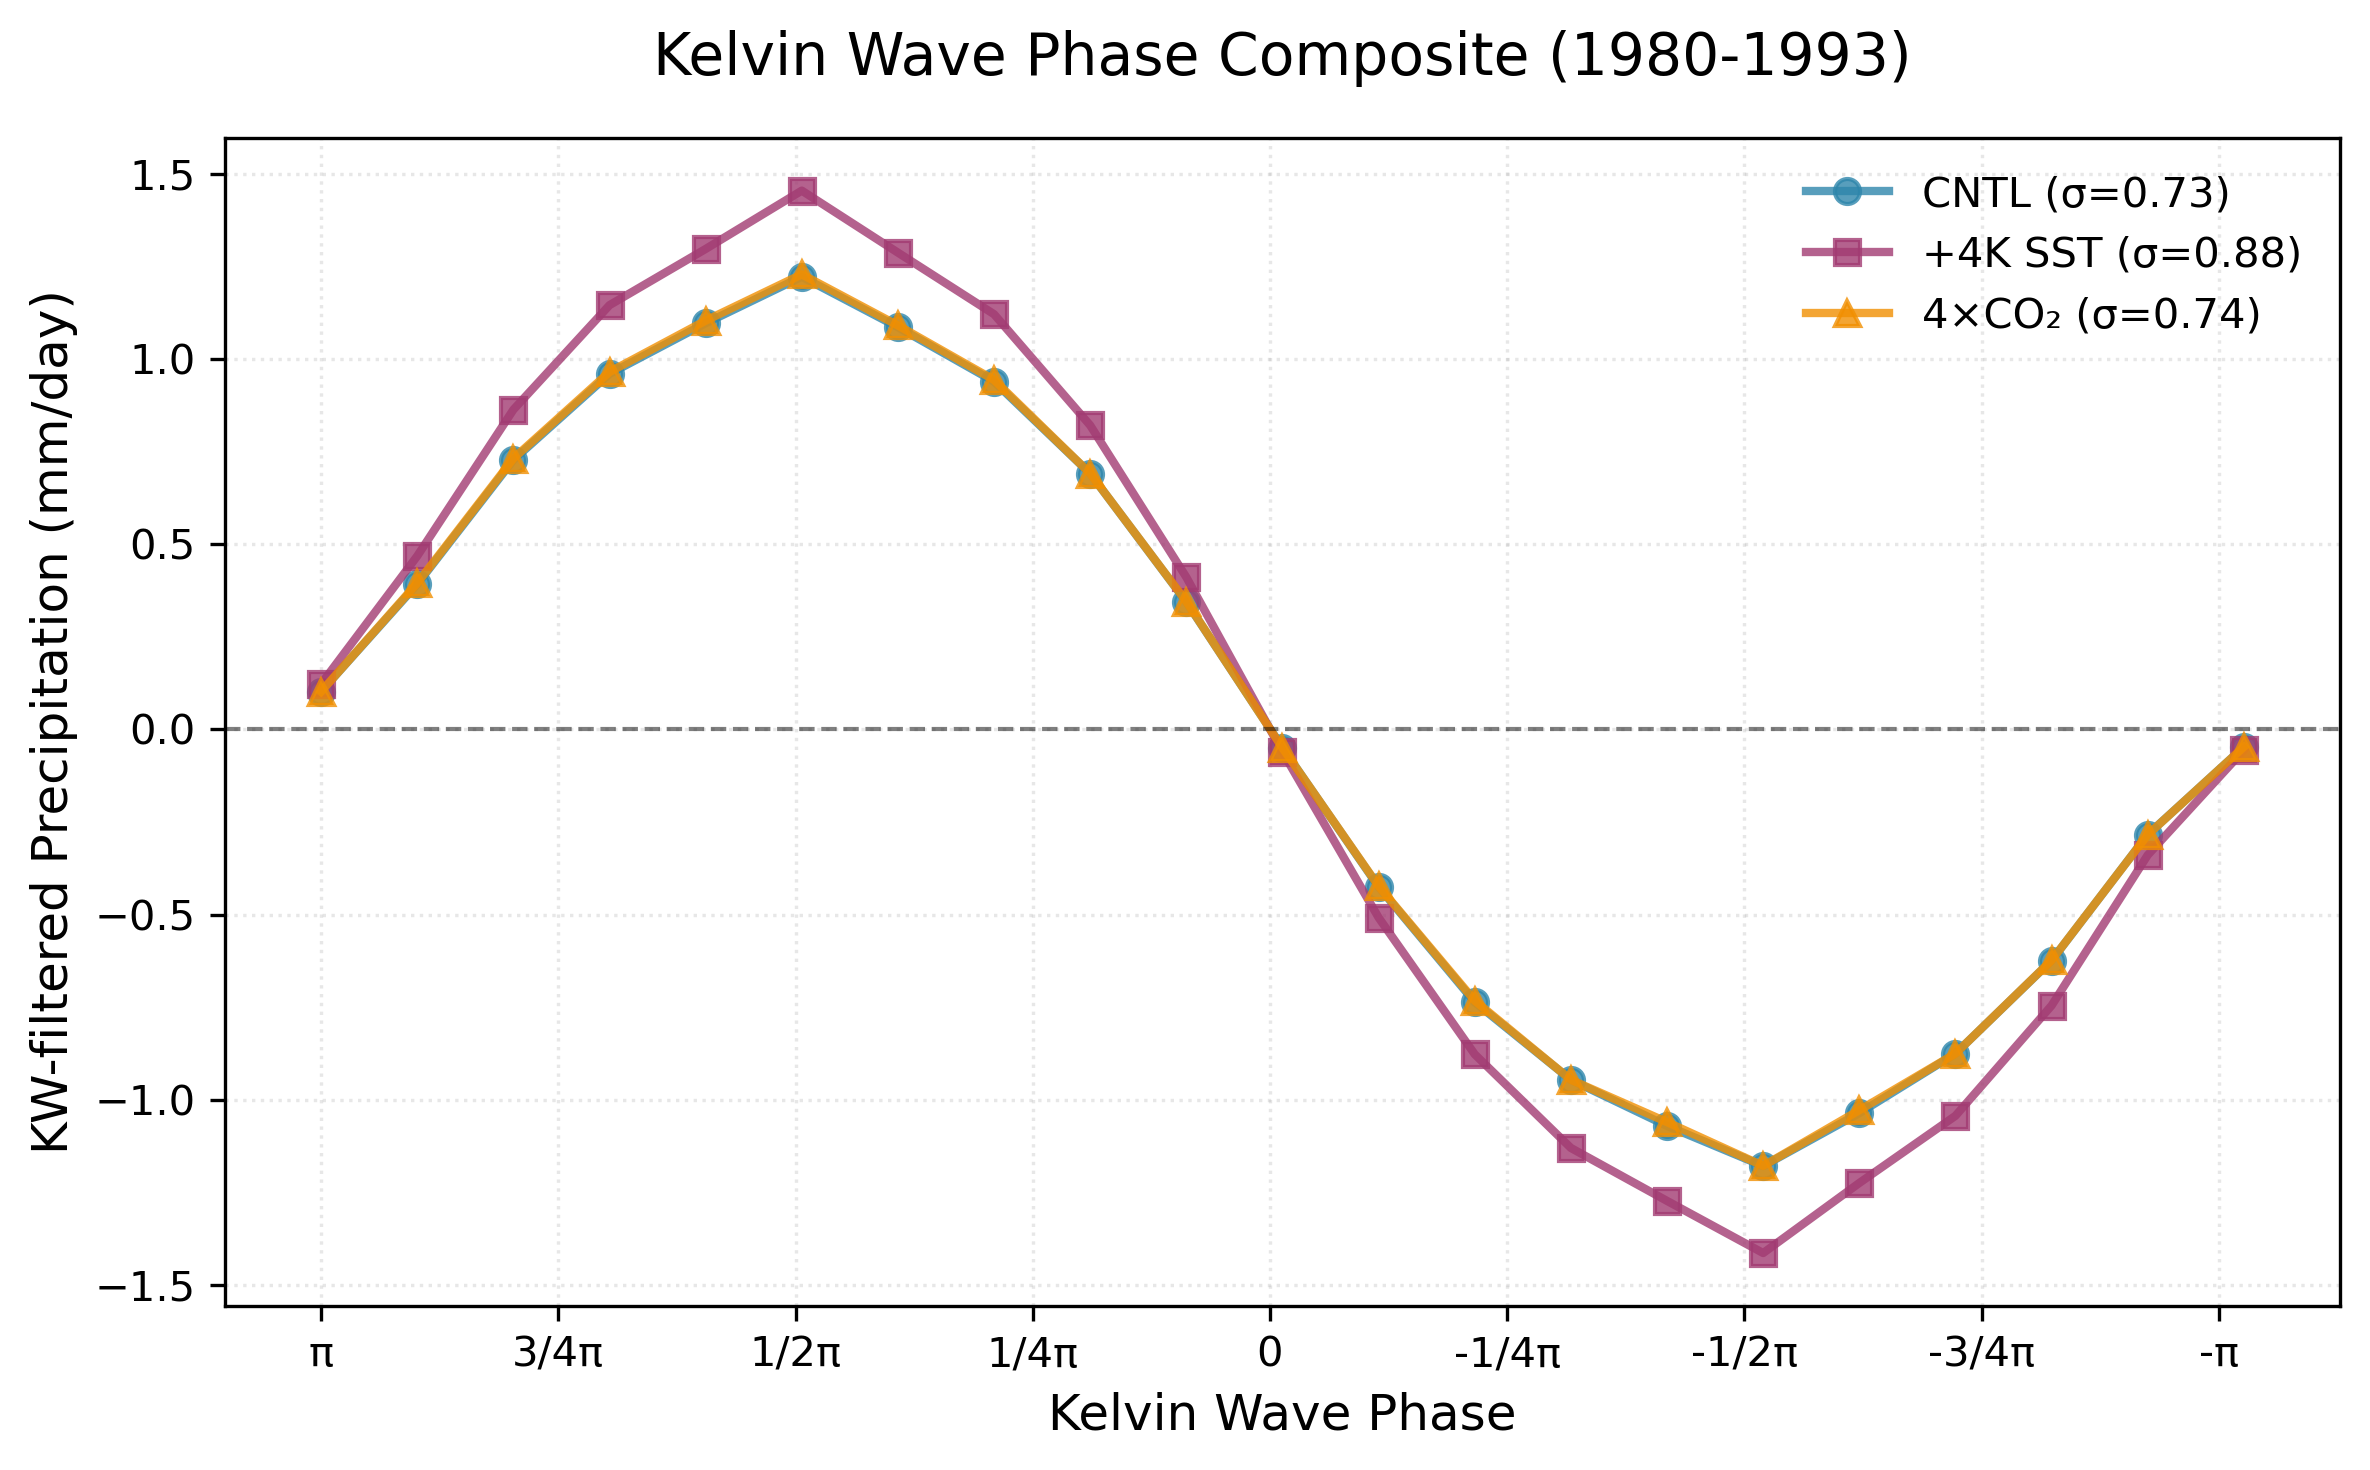

✅ Phase composite plotting completed


In [11]:
# Step 8: Plot phase composite comparison
print("="*70)
print("📊 Plotting phase composite comparison")
print("="*70)

fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=300)

experiments = ['CNTL', 'P4K', '4CO2']
colors = ['#2E86AB', '#A23B72', '#F18F01']
markers = ['o', 's', '^']
labels = ['CNTL', '+4K SST', '4×CO₂']

for i, (exp, color, marker, label) in enumerate(zip(experiments, colors, markers, labels)):
    phase_data = phase_composites[exp]
    ax.plot(
        phase_data['phase_bin'], 
        phase_data['composite_mean'],
        color=color,
        marker=marker,
        markersize=6,
        linewidth=2,
        label=f"{label} (σ={phase_data['std']:.2f})",
        alpha=0.8
    )

# Zero line
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)

# Format x-axis with π
PI = '\u03C0'
bin_simple = np.arange(-np.pi, np.pi + np.pi/4, np.pi/4)
ax.set_xticks(bin_simple)
ax.set_xticklabels([f'-{PI}', f'-3/4{PI}', f'-1/2{PI}', f'-1/4{PI}', '0', 
                    f'1/4{PI}', f'1/2{PI}', f'3/4{PI}', PI][::-1])

ax.set_xlabel('Kelvin Wave Phase', fontsize=12)
ax.set_ylabel('KW-filtered Precipitation (mm/day)', fontsize=12)
ax.set_title('Kelvin Wave Phase Composite (1980-1993)', fontsize=14, pad=15)

ax.legend(loc='best', fontsize=10, framealpha=0.9,frameon = False)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)

plt.tight_layout()

# Save figure
save_path = os.path.join(fig_save_dir, 'kelvin_wave_phase_composite_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Figure saved to: {save_path}")

plt.show()

print("="*70)
print("✅ Phase composite plotting completed")
print("="*70)

📈 Plotting lag-longitude Hovmöller diagrams

✅ Figure saved to: ./figures/Cal_cckws_std_distribution/kelvin_wave_lag_lon_composite_comparison.png


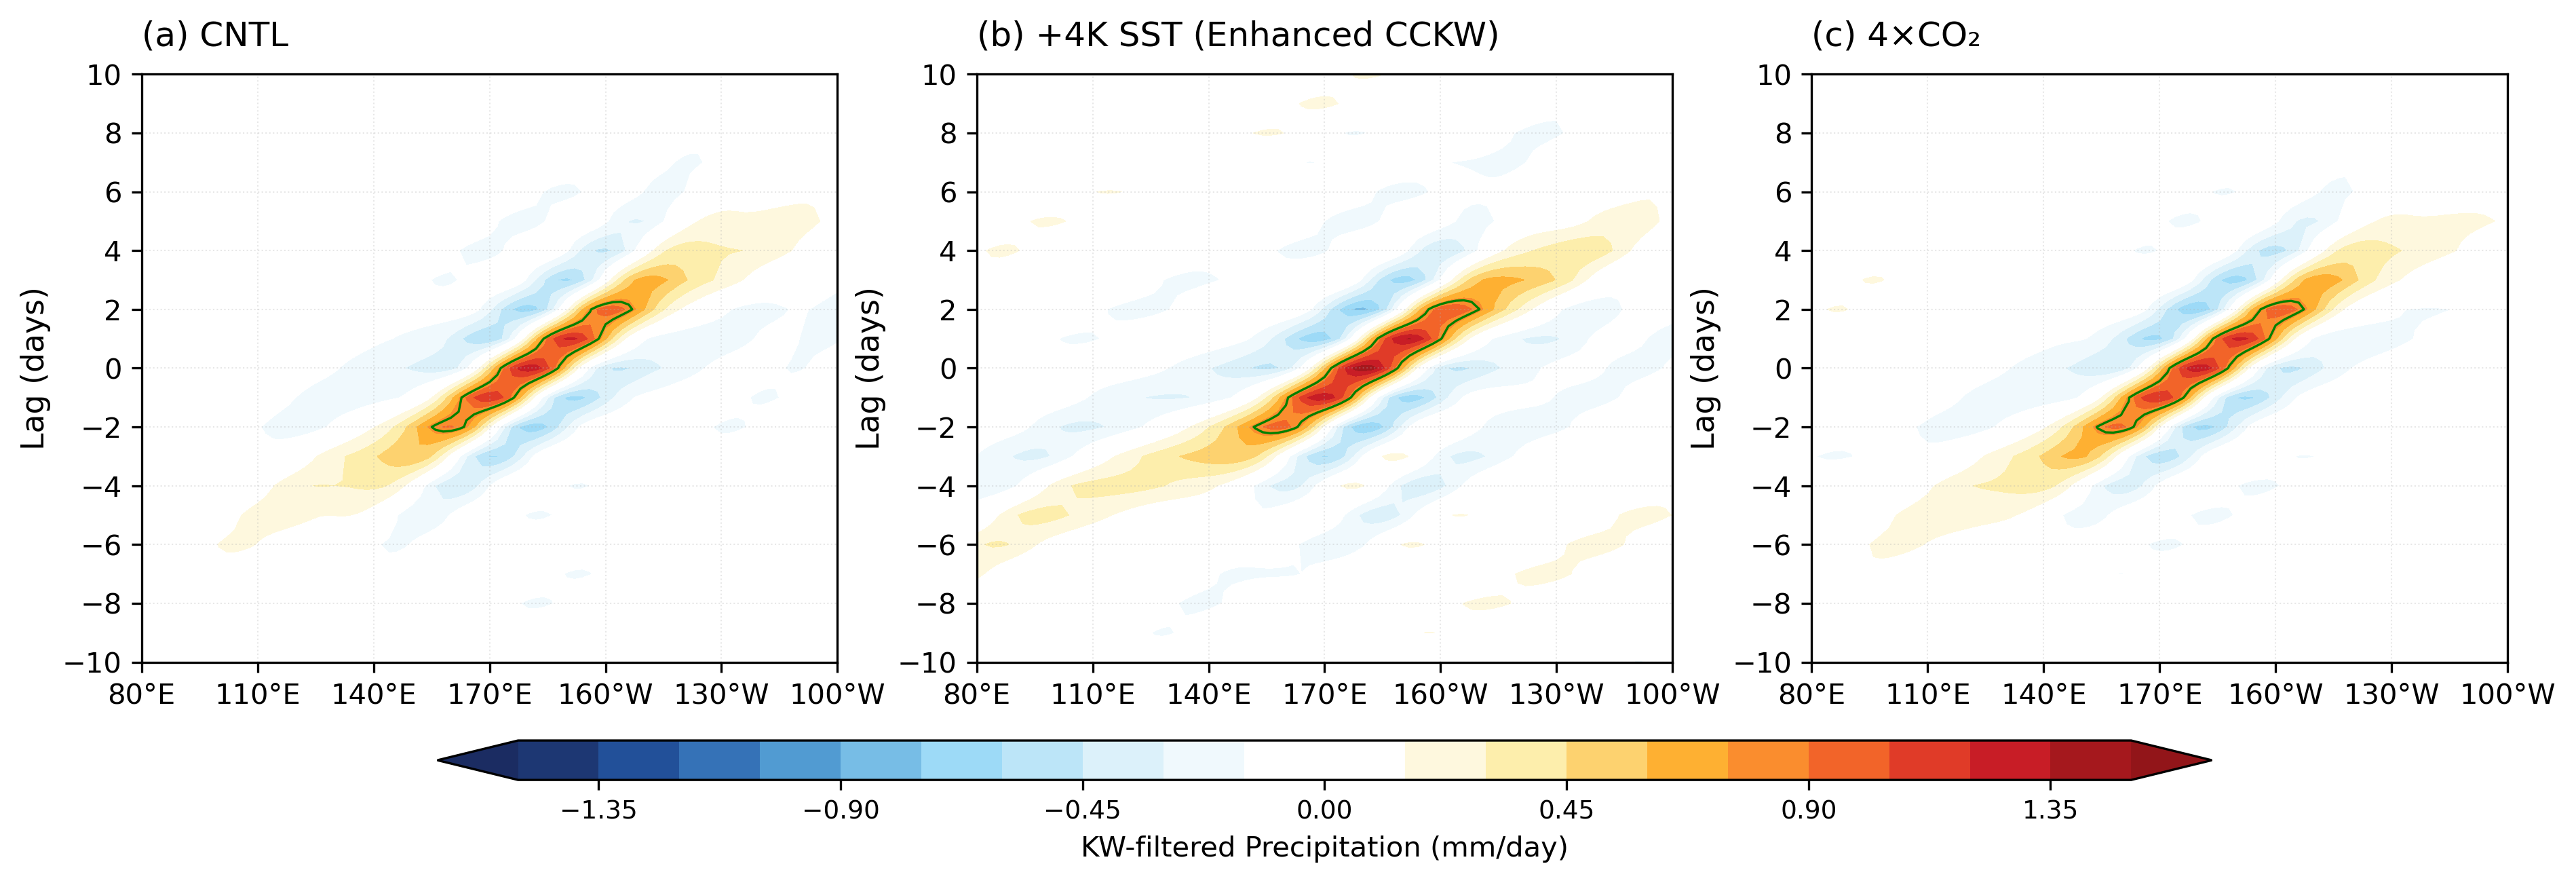

✅ Lag-longitude composite plotting completed


In [ ]:
# Step 9: Plot lag-longitude composite (Hovmöller diagram) comparison
print("="*70)
print("📈 Plotting lag-longitude Hovmöller diagrams")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

experiments = ['CNTL', 'P4K', '4CO2']

titles = ['(a) CNTL', '(b) +4K SST (Enhanced CCKW)', '(c) 4×CO₂']
# Determine common colorbar range
all_data = [lag_composites[exp]['lag_composite_kw'] for exp in experiments]
vmin = min([np.nanmin(d) for d in all_data])
vmax = max([np.nanmax(d) for d in all_data])

# Contour levels
clev = np.linspace(-1.5, 1.5, 21)
clev_pos = np.arange(0.8, vmax, 0.8)
clev_neg = np.arange(vmin, 0, 0.8)

for i, (exp, title, ax) in enumerate(zip(experiments, titles, axes)):
    lag_data = lag_composites[exp]
    tlag = lag_data['tlag']
    lon = lag_data['lon']
    composite_kw = lag_data['lag_composite_kw']
    n_events = lag_data['n_events']
    
    # Create meshgrid
    lont, tlon = np.meshgrid(lon, tlag)
    
    # Filled contour
    cf = ax.contourf(lont, tlon, composite_kw, 
                     levels=clev, 
                     cmap=cmaps.BlueWhiteOrangeRed, 
                     extend='both')
    
    # Line contours
    cn_p = ax.contour(lont, tlon, composite_kw, 
                      levels=clev_pos, 
                      colors='green', 
                      linewidths=0.8)
    cn_n = ax.contour(lont, tlon, composite_kw, 
                      levels=clev_neg, 
                      colors='green', 
                      linewidths=0.8,
                      linestyles='dashed')
    
    # Format
    ax.set_xlim([80, 260])
    ax.set_ylim([-nlag, nlag])
    ax.set_xticks(np.arange(80, 270, 30))
    ax.set_yticks(np.arange(-nlag, nlag+2, 2))
    
    ax.set_ylabel('Lag (days)', fontsize=11, )
  
    
    ax.set_title(f'{title}', fontsize=12, pad=10, loc = 'left')
    
    # Format longitude labels
    from cartopy.mpl.ticker import LongitudeFormatter
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    
    # Colorbar
cbar = plt.colorbar(cf, ax=axes, orientation='horizontal', pad=0.1, shrink=0.75, aspect=45)
cbar.set_label('KW-filtered Precipitation (mm/day)', fontsize=10)
cbar.ax.tick_params(labelsize=9)


# Save figure
save_path = os.path.join(fig_save_dir, 'kelvin_wave_lag_lon_composite_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Figure saved to: {save_path}")

plt.show()

print("="*70)
print("✅ Lag-longitude composite plotting completed")
print("="*70)


In [13]:
# Step 10: Find the base point with strongest CCKW activity
print("="*70)
print("🔍 Finding base point with strongest CCKW activity")
print("="*70)

# Define search region: Equatorial Pacific (5°N-15°N, 120°E-180°E)
lat_range = (5, 15)
lon_range = (120, 180)

base_points = {}

for exp in ['CNTL', 'P4K', '4CO2']:
    # Select region
    std_region = kelvin_std[exp].sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1])
    )
    
    # Find maximum STD location
    max_std = std_region.max().values
    max_loc = std_region.where(std_region == max_std, drop=True)
    
    base_lat = float(max_loc.lat.values)
    base_lon = float(max_loc.lon.values)
    
    base_points[exp] = {
        'lat': base_lat,
        'lon': base_lon,
        'std': max_std
    }
    
    print(f"✅ {exp}: Base point at ({base_lat:.1f}°N, {base_lon:.1f}°E), STD = {max_std:.3f} mm/day")

# Use a common base point (average of the three experiments)
common_lat = np.mean([base_points[exp]['lat'] for exp in ['CNTL', 'P4K', '4CO2']])
common_lon = np.mean([base_points[exp]['lon'] for exp in ['CNTL', 'P4K', '4CO2']])

print(f"\n📍 Common base point: ({common_lat:.1f}°N, {common_lon:.1f}°E)")
print("="*70)

🔍 Finding base point with strongest CCKW activity
✅ CNTL: Base point at (6.0°N, 180.0°E), STD = 2.868 mm/day
✅ P4K: Base point at (6.0°N, 180.0°E), STD = 3.423 mm/day
✅ 4CO2: Base point at (6.0°N, 180.0°E), STD = 2.928 mm/day

📍 Common base point: (6.0°N, 180.0°E)


/tmp/ipykernel_1203464/1610513038.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_lat = float(max_loc.lat.values)
/tmp/ipykernel_1203464/1610513038.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_lon = float(max_loc.lon.values)
/tmp/ipykernel_1203464/1610513038.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_lat = float(max_loc.lat.values)
/tmp/ipykernel_1203464/1610513038.py:24: DeprecationWarning: Conversion of an array with ndim > 0

In [14]:
# Step 11: Detect CCKW events using local minima method
print("="*70)
print("🌊 Detecting CCKW events (local minima in precipitation)")
print("="*70)

def detect_cckw_events(data, base_lat, base_lon, window=4, threshold_std=0.5):
    """
    Detect CCKW events based on local MAXIMA in KW-filtered precipitation.
    
    Following Straub and Kiladis (2002): A CCKW event is defined when the target 
    domain experiences a single local maximum of precipitation anomalies (day 0) 
    compared to adjacent days (from days -4 to +4).
    
    Parameters:
    -----------
    data : xr.DataArray
        KW-filtered precipitation data (time, lat, lon)
    base_lat : float
        Latitude of base point
    base_lon : float
        Longitude of base point
    window : int
        Days before and after to check for local maximum (default: 4)
    threshold_std : float
        Threshold in standard deviations for event detection (default: 0.5)
    
    Returns:
    --------
    event_indices : np.ndarray
        Array of time indices where events occur (day 0)
    event_values : np.ndarray
        Precipitation values at event times
    """
    # Extract time series at base point (average over nearby points for robustness)
    lat_window = 2  # ±2 degrees
    lon_window = 2
    
    ts = data.sel(
        lat=slice(base_lat-lat_window, base_lat+lat_window),
        lon=slice(base_lon-lon_window, base_lon+lon_window)
    ).mean(dim=['lat', 'lon'])
    
    ts_values = ts.values
    ts_std = np.nanstd(ts_values)
    
    # For precipitation: HIGH values = active convection (opposite of OLR)
    # We look for local MAXIMA in KW-filtered precipitation
    event_indices = []
    event_values = []
    
    # Check each time point
    for i in range(window, len(ts_values) - window):
        center_val = ts_values[i]
        
        # Check if it's above threshold
        if center_val < threshold_std * ts_std:
            continue
        
        # Check if it's a local maximum compared to days [-4, +4]
        window_vals = np.concatenate([
            ts_values[i-window:i],
            ts_values[i+1:i+window+1]
        ])
        
        # Must be strictly greater than all surrounding values
        if center_val > np.nanmax(window_vals):
            event_indices.append(i)
            event_values.append(center_val)
    
    print(f"     Detected {len(event_indices)} events")
    print(f"     Time series STD: {ts_std:.3f} mm/day")
    if len(event_values) > 0:
        print(f"     Mean event amplitude: {np.mean(event_values):.3f} mm/day")
        print(f"     Event amplitude range: [{np.min(event_values):.3f}, {np.max(event_values):.3f}] mm/day")
    
    return np.array(event_indices), np.array(event_values)

# Detect events for each experiment
cckw_events = {}

for exp in ['CNTL', 'P4K', '4CO2']:
    print(f"\n📍 {exp}:")
    
    event_idx, event_vals = detect_cckw_events(
        kelvin_wave_data[exp],
        common_lat,
        common_lon,
        window=4,
        threshold_std=1.0
    )
    
    cckw_events[exp] = {
        'indices': event_idx,
        'values': event_vals,
        'times': kelvin_wave_data[exp].time.values[event_idx]
    }

print("\n" + "="*70)
print("✅ Event detection completed")
print("="*70)

🌊 Detecting CCKW events (local minima in precipitation)

📍 CNTL:
     Detected 379 events
     Time series STD: 1.649 mm/day
     Mean event amplitude: 2.985 mm/day
     Event amplitude range: [1.653, 8.387] mm/day

📍 P4K:
     Detected 406 events
     Time series STD: 1.922 mm/day
     Mean event amplitude: 3.421 mm/day
     Event amplitude range: [1.924, 8.473] mm/day

📍 4CO2:
     Detected 369 events
     Time series STD: 1.632 mm/day
     Mean event amplitude: 3.017 mm/day
     Event amplitude range: [1.642, 9.286] mm/day

✅ Event detection completed


In [15]:
# Step 12: Create event-centered composite with significance testing
print("="*70)
print("📊 Creating event-centered composites with significance testing")
print("="*70)

from scipy import stats

def event_composite_with_significance(data, event_indices, nlag=15, lat_avg_range=(-10, 10)):
    """
    Create lag-longitude composite centered on detected events with significance testing.
    
    Parameters:
    -----------
    data : xr.DataArray
        KW-filtered precipitation data (time, lat, lon)
    event_indices : np.ndarray
        Time indices of detected events
    nlag : int
        Number of lag days before and after event
    lat_avg_range : tuple
        Latitude range for averaging
    
    Returns:
    --------
    lag_composite : np.ndarray
        Composite values (2*nlag+1, nlon)
    significance : np.ndarray
        95% significance mask (2*nlag+1, nlon)
    """
    # Average over latitude
    data_avg = data.sel(lat=slice(lat_avg_range[0], lat_avg_range[1])).mean(dim='lat')
    
    nlon = len(data_avg.lon)
    n_events = len(event_indices)
    
    # Storage for individual event composites
    composites = np.zeros((n_events, 2*nlag+1, nlon))
    composites[:] = np.nan
    
    # Extract composites for each event
    valid_events = 0
    for i, event_idx in enumerate(event_indices):
        if event_idx - nlag < 0 or event_idx + nlag >= len(data_avg.time):
            continue
        
        for lag in range(-nlag, nlag+1):
            composites[valid_events, lag+nlag, :] = data_avg.isel(time=event_idx+lag).values
        
        valid_events += 1
    
    # Trim to valid events
    composites = composites[:valid_events, :, :]
    
    # Calculate mean composite
    lag_composite = np.nanmean(composites, axis=0)
    
    # Significance testing using t-test
    # H0: mean = 0 (no signal)
    significance = np.zeros_like(lag_composite, dtype=bool)
    
    for lag_idx in range(2*nlag+1):
        for lon_idx in range(nlon):
            values = composites[:, lag_idx, lon_idx]
            values = values[~np.isnan(values)]
            
            if len(values) > 2:
                t_stat, p_value = stats.ttest_1samp(values, 0)
                if p_value < 0.05:  # 95% significance
                    significance[lag_idx, lon_idx] = True
    
    print(f"     Valid events: {valid_events}")
    print(f"     Significant points: {np.sum(significance)} / {significance.size} "
          f"({100*np.sum(significance)/significance.size:.1f}%)")
    
    return lag_composite, significance, valid_events

# Create composites for each experiment
event_composites = {}

for exp in ['CNTL', 'P4K', '4CO2']:
    print(f"\n📍 {exp}:")
    
    composite, significance, n_valid = event_composite_with_significance(
        kelvin_wave_data[exp],
        cckw_events[exp]['indices'],
        nlag=15,
        lat_avg_range=(-10, 10)
    )
    
    event_composites[exp] = {
        'composite': composite,
        'significance': significance,
        'n_events': n_valid,
        'lags': np.arange(-15, 16),
        'lon': kelvin_wave_data[exp].lon.values
    }

print("\n" + "="*70)
print("✅ Event composites created")
print("="*70)

📊 Creating event-centered composites with significance testing

📍 CNTL:


     Valid events: 379
     Significant points: 1196 / 5580 (21.4%)

📍 P4K:
     Valid events: 406
     Significant points: 1281 / 5580 (23.0%)

📍 4CO2:
     Valid events: 369
     Significant points: 1368 / 5580 (24.5%)

✅ Event composites created


🎨 Plotting event-centered Hovmöller diagrams with ENHANCED visualization

Global color scale: [-1.183, 1.183] mm/day

CNTL Statistics:
  Range: [-0.528, 1.059] mm/day
  Max absolute: 1.059 mm/day
  Significant area: 21.4%

P4K Statistics:
  Range: [-0.601, 1.183] mm/day
  Max absolute: 1.183 mm/day
  Significant area: 23.0%

4CO2 Statistics:
  Range: [-0.544, 1.107] mm/day
  Max absolute: 1.107 mm/day
  Significant area: 24.5%

✅ Figure saved to: ./figures/Cal_cckws_std_distribution/cckw_event_centered_hovmoller_enhanced.png


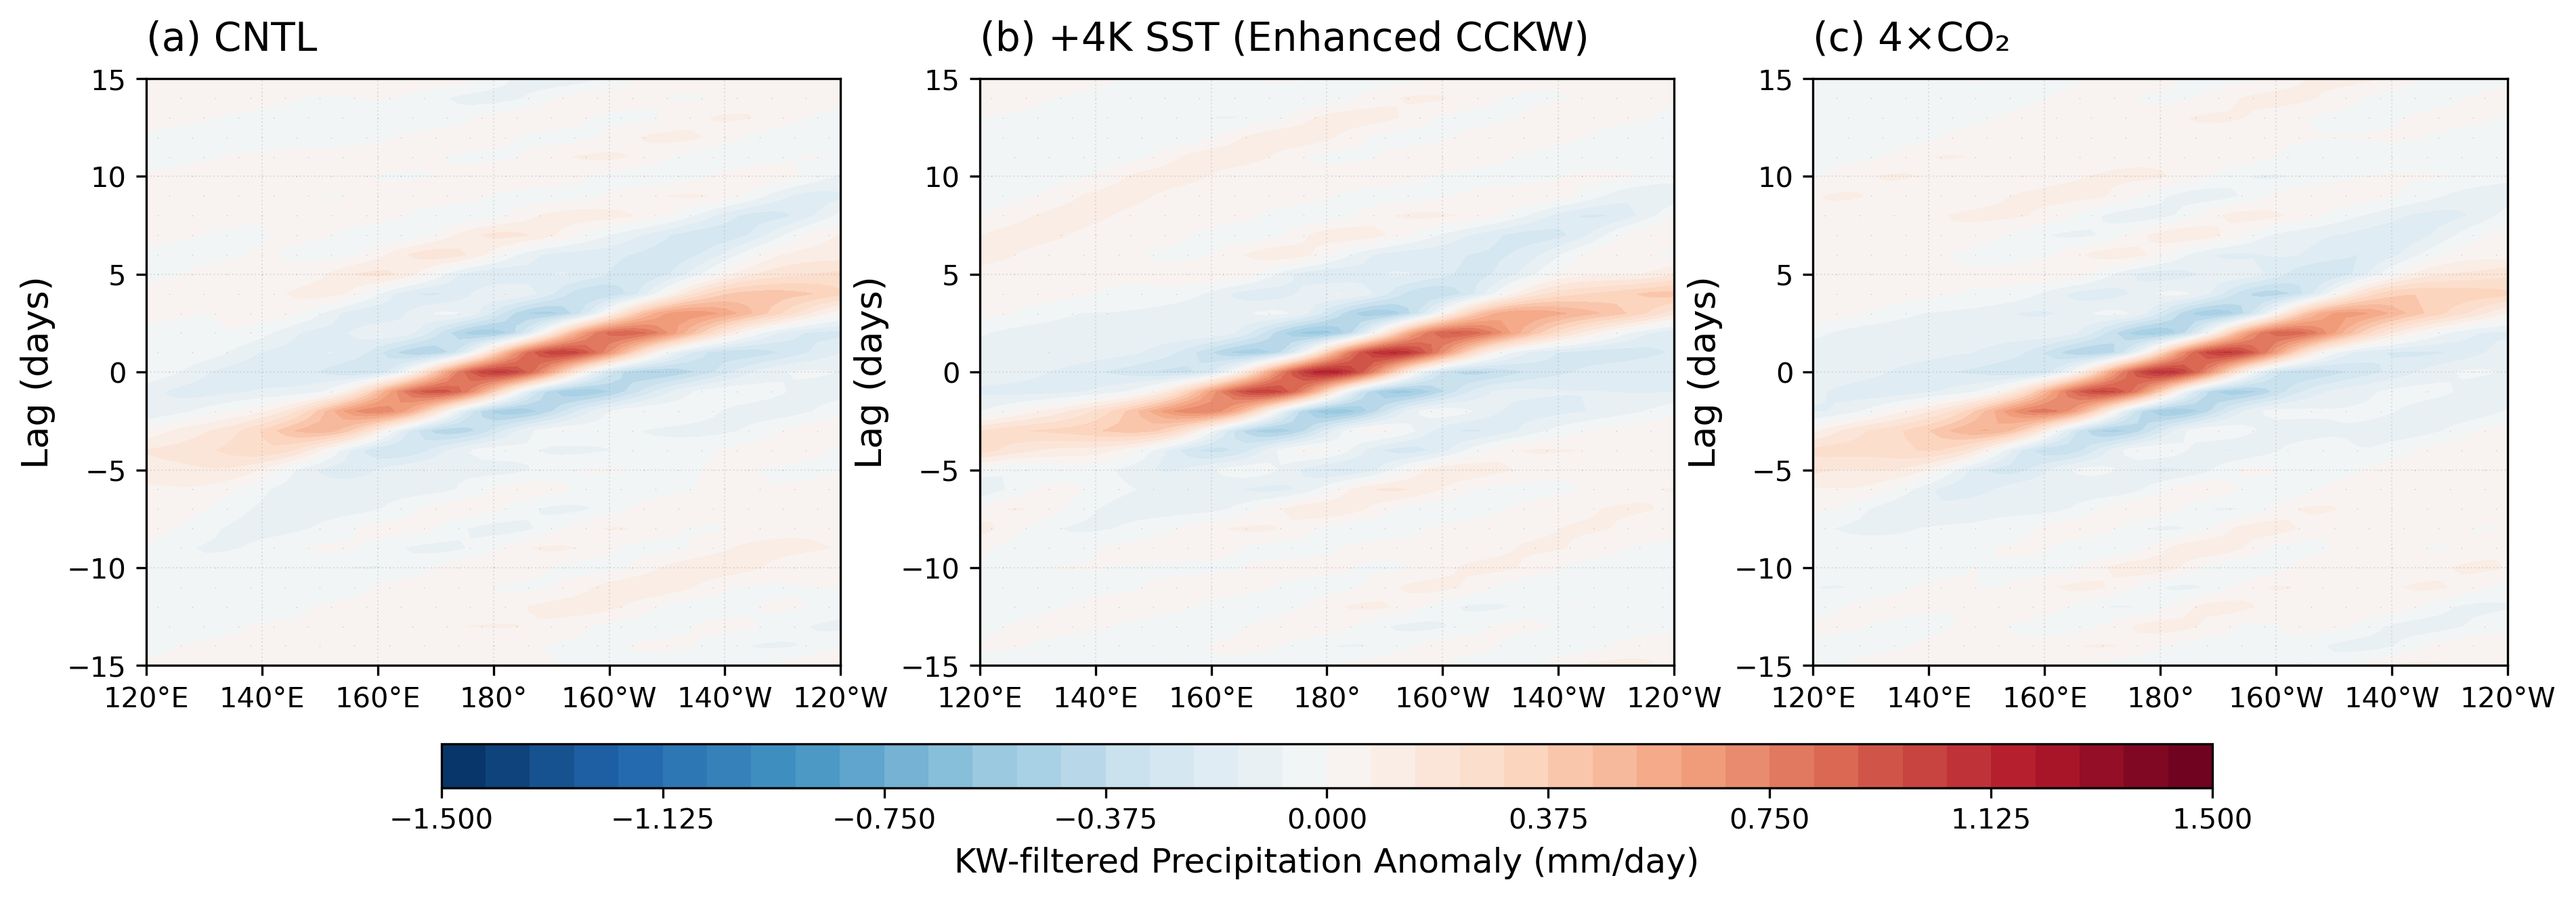

✅ Enhanced Hovmöller plotting completed


In [16]:
# Step 13: Plot event-centered Hovmöller diagrams with significance (Enhanced Design)
print("="*70)
print("🎨 Plotting event-centered Hovmöller diagrams with ENHANCED visualization")
print("="*70)

# Create custom colormap with enhanced contrast
from matplotlib.colors import LinearSegmentedColormap
def create_precip_cmap():
    """Create diverging colormap: blue (wet) - gray - orange/red (dry)"""
    colors = [
        '#053061',  # dark blue (strong wet)
        '#2166ac',  # blue
        '#4393c3',  # light blue
        '#92c5de',  # pale blue
        '#d1e5f0',  # very pale blue
        '#f7f7f7',  # white/neutral
        '#fddbc7',  # very pale orange
        '#f4a582',  # pale orange
        '#d6604d',  # light red
        '#b2182b',  # red
        '#67001f',  # dark red (strong dry)
    ]
    return LinearSegmentedColormap.from_list('precip_div', colors, N=256)

precip_cmap = create_precip_cmap()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

experiments = ['CNTL', 'P4K', '4CO2']
titles = ['(a) CNTL', '(b) +4K SST (Enhanced CCKW)', '(c) 4×CO₂']

# Use COMMON colorbar range to show relative differences
all_composites = [event_composites[exp]['composite'] for exp in experiments]
global_max = max([np.nanmax(np.abs(c)) for c in all_composites])
global_vmax = global_max
global_vmin = -global_max

print(f"\nGlobal color scale: [{global_vmin:.3f}, {global_vmax:.3f}] mm/day")

for i, (exp, title, ax) in enumerate(zip(experiments, titles, axes)):
    comp_data = event_composites[exp]
    lags = comp_data['lags']
    lon = comp_data['lon']
    composite = comp_data['composite']
    significance = comp_data['significance']
    n_events = comp_data['n_events']
    
    # Calculate statistics
    comp_max = np.nanmax(composite)
    comp_min = np.nanmin(composite)
    comp_mean = np.nanmean(composite[significance])
    sig_percent = 100 * np.sum(significance) / significance.size
    
    print(f"\n{exp} Statistics:")
    print(f"  Range: [{comp_min:.3f}, {comp_max:.3f}] mm/day")
    print(f"  Max absolute: {max(abs(comp_min), abs(comp_max)):.3f} mm/day")
    print(f"  Significant area: {sig_percent:.1f}%")
    
    # Use common color scale
    clev = np.linspace(-1.5, 1.5, 41)
    clev_pos = np.arange(0.25, global_vmax, 0.25)
    clev_neg = np.arange(global_vmin, -0.25, 0.25)
    
    # Create meshgrid
    lon_grid, lag_grid = np.meshgrid(lon, lags)
    
    # Strategy: Show all data, but use stippling for non-significant areas
    # Plot ALL composite data
    cf = ax.contourf(lon_grid, lag_grid, composite,
                     levels=clev,
                     cmap=precip_cmap,
                     extend='neither')

    # Add stippling (dots) for non-significant regions
    # This clearly marks where the signal is not reliable
    non_sig = ~significance
    if np.sum(non_sig) > 0:
        # Create a mask for stippling
        lon_subset = lon_grid[non_sig]
        lag_subset = lag_grid[non_sig]
        # Downsample stippling for cleaner look (every 3rd point)
        step = 3
        ax.scatter(lon_subset[::step], lag_subset[::step], 
                  s=0.5, c='gray', alpha=0.4, marker='.', 
                  linewidths=0, rasterized=True)
    
    # Contour lines ONLY for significant positive values (wet phase)
    
    
    # Contour lines ONLY for significant negative values (dry phase)

    
    # Format axes
    ax.set_xlim([120, 240])
    ax.set_ylim([-15, 15])
    ax.set_xticks(np.arange(120, 250, 20))
    ax.set_yticks(np.arange(-15, 16, 5))
    
    ax.set_ylabel('Lag (days)', fontsize=13, )
   
    # Title with event count and significance info
    ax.set_title(f'{title}' , 
                fontsize=14,  loc='left', pad=10)
    
    # Format longitude labels
    from cartopy.mpl.ticker import LongitudeFormatter
    lon_formatter = LongitudeFormatter()
    ax.set_xticklabels([lon_formatter(x) for x in ax.get_xticks()])
    
    # Grid
    ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5, color='gray', zorder=1)
    
    # Colorbar (only for bottom panel to save space)
    if i == 2:
        cbar = plt.colorbar(cf, ax=axes, orientation='horizontal', 
                           pad=0.1, shrink=0.75, aspect=40)
        cbar.set_label('KW-filtered Precipitation Anomaly (mm/day)', 
                      fontsize=12, )
        cbar.ax.tick_params(labelsize=10)
    
    # Compact annotation box
    textstr = f'[{comp_min:.2f}, {comp_max:.2f}] mm/day'
    props = dict(boxstyle='round,pad=0.4', facecolor='white', 
                edgecolor='gray', alpha=0.92, linewidth=1.5)




# Save figure
save_path = os.path.join(fig_save_dir, 'cckw_event_centered_hovmoller_enhanced.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Figure saved to: {save_path}")

plt.show()

print("="*70)
print("✅ Enhanced Hovmöller plotting completed")
print("="*70)